# MATH/CSCI 485 — Assignment 3: Image Compression via Block-wise SVD

## Objective
This notebook explores **Singular Value Decomposition (SVD)** for compressing grayscale images.
---

## 1. Imports & Setup

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# Creating output directory for saving compressed images
os.makedirs('compressed_images', exist_ok=True)
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Preprocessing

We are generating a synthetic 256×256 grayscale image

Loaded real image
Image shape: (552, 984) | Min: 0.0 | Max: 255.0


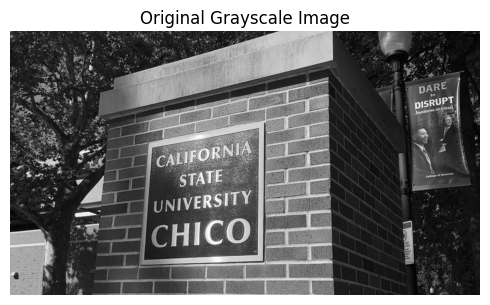

In [17]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# Define path properly
IMAGE_PATH = Path("chico_wall.jpg")

def load_and_preprocess_image(path=IMAGE_PATH, size=(256, 256)):
    
    if path and Path(path).exists():
        img = Image.open(path).convert('L')
        print("Loaded real image")
    else:
        print('No valid image path — generating synthetic test image.')
        np.random.seed(42)
        x = np.linspace(0, 4 * np.pi, size[0])
        y = np.linspace(0, 4 * np.pi, size[1])
        xx, yy = np.meshgrid(x, y)
        data = (np.sin(xx) * np.cos(yy) * 127 + 127).astype(np.uint8)
        data += np.random.randint(0, 20, size=data.shape, dtype=np.uint8)
        img = Image.fromarray(data, mode='L')

    w, h = img.size
    new_w = (w // 8) * 8
    new_h = (h // 8) * 8
    img = img.resize((new_w, new_h), Image.LANCZOS)

    img_array = np.array(img, dtype=np.float64)
    print(f'Image shape: {img_array.shape} | Min: {img_array.min():.1f} | Max: {img_array.max():.1f}')
    return img_array


# ---------- Loading image ----------
image = load_and_preprocess_image()   

os.makedirs('compressed_images', exist_ok=True)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title('Original Grayscale Image')
plt.axis('off')
plt.tight_layout()
plt.savefig('compressed_images/original.png', dpi=100)
plt.show()

## 3. Block-wise SVD — Core Functions



In [18]:
def compress_block(block, k):
    
    U, S, Vt = np.linalg.svd(block, full_matrices=True)
    # Keep only top-k components
    U_k  = U[:, :k]          # shape: (8, k)
    S_k  = np.diag(S[:k])    # shape: (k, k)
    Vt_k = Vt[:k, :]         # shape: (k, 8)
    reconstructed = U_k @ S_k @ Vt_k
    return reconstructed


def compress_image(image, k, block_size=8):
    
    H, W = image.shape
    compressed = np.zeros_like(image)

    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            block = image[i:i+block_size, j:j+block_size]
            compressed[i:i+block_size, j:j+block_size] = compress_block(block, k)

   
    compressed = np.clip(compressed, 0, 255)
    return compressed


def compression_ratio(k, block_size=8):
    
    original = block_size ** 2
    stored   = k * (block_size + block_size + 1)
    return original / stored


def frobenius_error(original, reconstructed):
    """Mean Frobenius norm error across the image."""
    return np.linalg.norm(original - reconstructed, 'fro') / original.size


def psnr(original, reconstructed):
    """Peak Signal-to-Noise Ratio (higher = better quality)."""
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10((255 ** 2) / mse)


print('Core SVD functions defined.')

Core SVD functions defined.


## 4. Run Compression for k = 1 to 8

We are iterating over every value of *k*, compressing the full image, computing the metrics, and saving each result.

In [19]:
k_values      = list(range(1, 9))
comp_ratios   = []
frob_errors   = []
psnr_values   = []
compressed_images = {}

for k in k_values:
    comp_img  = compress_image(image, k)
    cr        = compression_ratio(k)
    err       = frobenius_error(image, comp_img)
    psnr_val  = psnr(image, comp_img)

    comp_ratios.append(cr)
    frob_errors.append(err)
    psnr_values.append(psnr_val)
    compressed_images[k] = comp_img

    # Saving image
    out_img = Image.fromarray(comp_img.astype(np.uint8))
    out_img.save(f'compressed_images/k_{k}.png')

    print(f'k={k}  |  Compression Ratio: {cr:.4f}  |  Frobenius Error: {err:.4f}  |  PSNR: {psnr_val:.2f} dB')

print('\nAll compressions complete.')

k=1  |  Compression Ratio: 3.7647  |  Frobenius Error: 0.0170  |  PSNR: 26.19 dB
k=2  |  Compression Ratio: 1.8824  |  Frobenius Error: 0.0095  |  PSNR: 31.23 dB
k=3  |  Compression Ratio: 1.2549  |  Frobenius Error: 0.0055  |  PSNR: 35.98 dB
k=4  |  Compression Ratio: 0.9412  |  Frobenius Error: 0.0031  |  PSNR: 40.95 dB
k=5  |  Compression Ratio: 0.7529  |  Frobenius Error: 0.0016  |  PSNR: 46.76 dB
k=6  |  Compression Ratio: 0.6275  |  Frobenius Error: 0.0007  |  PSNR: 54.19 dB
k=7  |  Compression Ratio: 0.5378  |  Frobenius Error: 0.0002  |  PSNR: 65.11 dB
k=8  |  Compression Ratio: 0.4706  |  Frobenius Error: 0.0000  |  PSNR: 298.01 dB

All compressions complete.


## 5. Visualization

### 5a. Compression Ratio and Reconstruction Error vs. k

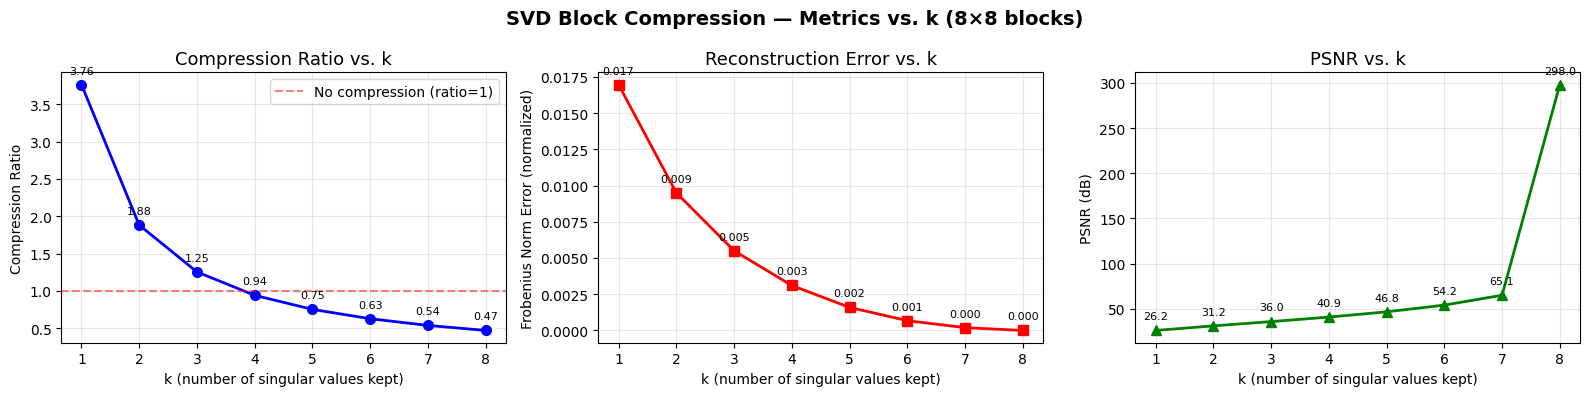

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1 — Compression Ratio
axes[0].plot(k_values, comp_ratios, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Compression Ratio vs. k', fontsize=13)
axes[0].set_xlabel('k (number of singular values kept)')
axes[0].set_ylabel('Compression Ratio')
axes[0].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='No compression (ratio=1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for x, y in zip(k_values, comp_ratios):
    axes[0].annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

# Plot 2 — Frobenius Error
axes[1].plot(k_values, frob_errors, 'rs-', linewidth=2, markersize=7)
axes[1].set_title('Reconstruction Error vs. k', fontsize=13)
axes[1].set_xlabel('k (number of singular values kept)')
axes[1].set_ylabel('Frobenius Norm Error (normalized)')
axes[1].grid(True, alpha=0.3)
for x, y in zip(k_values, frob_errors):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

# Plot 3 — PSNR
axes[2].plot(k_values, psnr_values, 'g^-', linewidth=2, markersize=7)
axes[2].set_title('PSNR vs. k', fontsize=13)
axes[2].set_xlabel('k (number of singular values kept)')
axes[2].set_ylabel('PSNR (dB)')
axes[2].grid(True, alpha=0.3)
for x, y in zip(k_values, psnr_values):
    axes[2].annotate(f'{y:.1f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

plt.suptitle('SVD Block Compression — Metrics vs. k (8×8 blocks)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('compressed_images/metrics_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### 5b. Visual Comparison of Reconstructed Images Across k Values

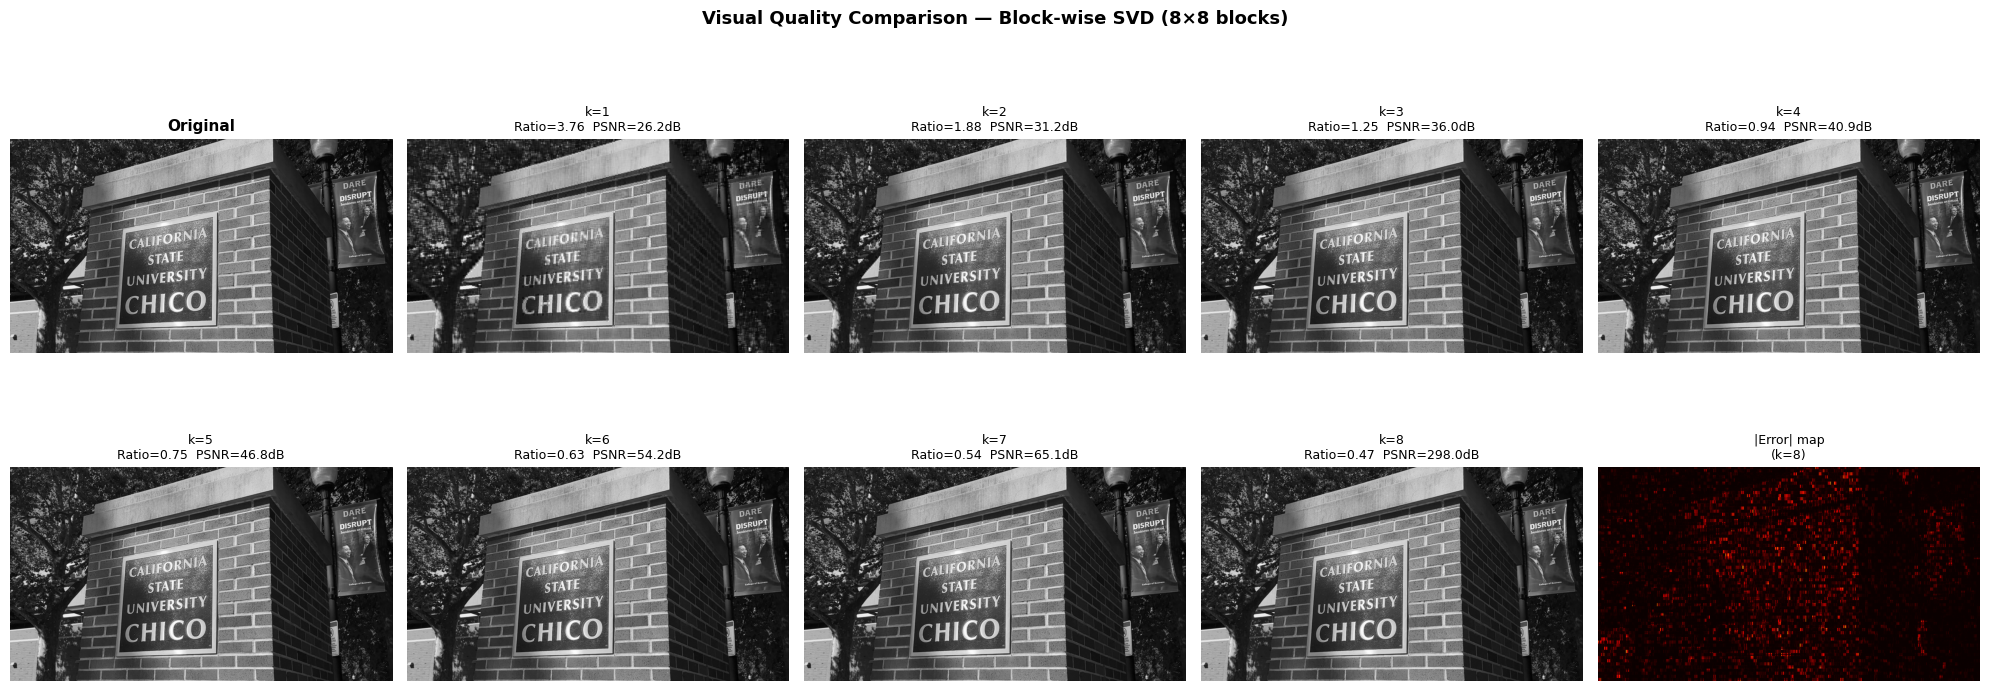

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Original
axes[0, 0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

# k = 1 to 4 in top row
for idx, k in enumerate([1, 2, 3, 4]):
    axes[0, idx+1].imshow(compressed_images[k], cmap='gray', vmin=0, vmax=255)
    axes[0, idx+1].set_title(f'k={k}\nRatio={comp_ratios[k-1]:.2f}  PSNR={psnr_values[k-1]:.1f}dB', fontsize=9)
    axes[0, idx+1].axis('off')

# k = 5 to 8 in bottom row, and blank last cell
for idx, k in enumerate([5, 6, 7, 8]):
    axes[1, idx].imshow(compressed_images[k], cmap='gray', vmin=0, vmax=255)
    axes[1, idx].set_title(f'k={k}\nRatio={comp_ratios[k-1]:.2f}  PSNR={psnr_values[k-1]:.1f}dB', fontsize=9)
    axes[1, idx].axis('off')

# Filling last subplot with difference map for k=8
diff = np.abs(image - compressed_images[8])
axes[1, 4].imshow(diff, cmap='hot')
axes[1, 4].set_title('|Error| map\n(k=8)', fontsize=9)
axes[1, 4].axis('off')

plt.suptitle('Visual Quality Comparison — Block-wise SVD (8×8 blocks)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('compressed_images/visual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. [Optional] Experiment with Other Block Sizes

Here we are comparing block sizes **4×4, 8×8, and 16×16** at a fixed *k=4* 

Comparing block sizes at fixed k=4

  Block Size     Comp. Ratio     Frob. Error     PSNR (dB)
----------------------------------------------------------
         4x4          0.4444          0.0000        301.21
         8x8          0.9412          0.0031         40.95
        16x16          1.9394          0.0086         32.09


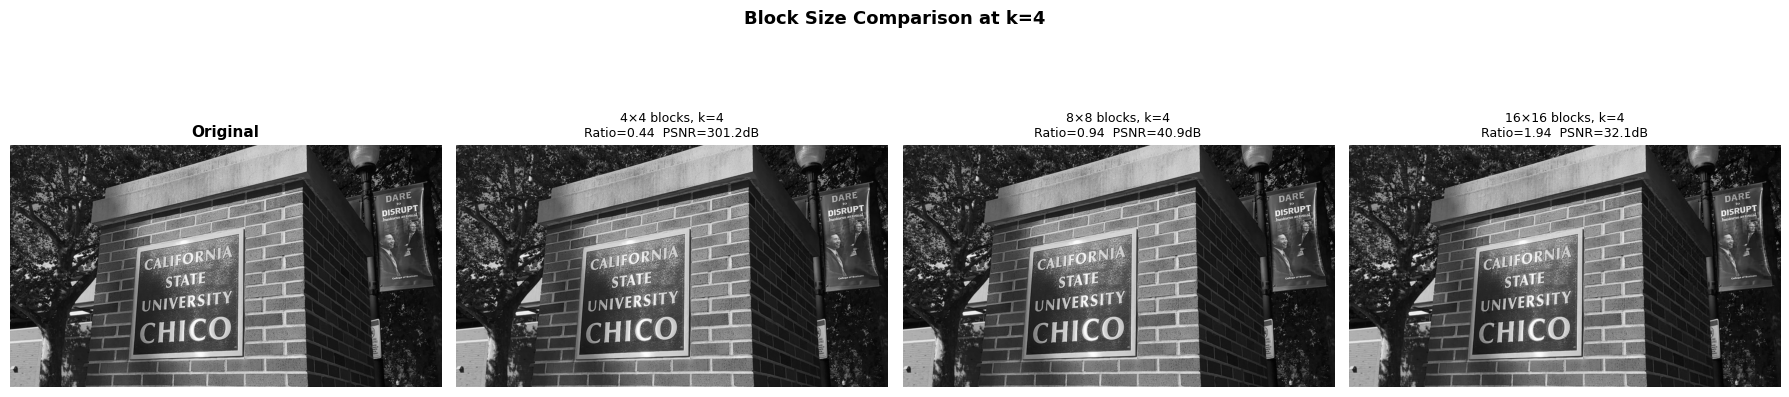

In [22]:
block_sizes = [4, 8, 16]
k_fixed = 4

print(f'Comparing block sizes at fixed k={k_fixed}\n')
print(f'{'Block Size':>12}  {'Comp. Ratio':>14}  {'Frob. Error':>14}  {'PSNR (dB)':>12}')
print('-' * 58)

fig, axes = plt.subplots(1, len(block_sizes) + 1, figsize=(18, 5))
axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original', fontsize=11, fontweight='bold')
axes[0].axis('off')

for idx, bs in enumerate(block_sizes):
    comp_img = compress_image(image, k=min(k_fixed, bs), block_size=bs)
    cr  = bs**2 / (min(k_fixed, bs) * (bs + bs + 1))
    err = frobenius_error(image, comp_img)
    p   = psnr(image, comp_img)
    print(f'{bs:>10}x{bs:<1}  {cr:>14.4f}  {err:>14.4f}  {p:>12.2f}')

    axes[idx+1].imshow(comp_img, cmap='gray', vmin=0, vmax=255)
    axes[idx+1].set_title(f'{bs}×{bs} blocks, k={min(k_fixed,bs)}\nRatio={cr:.2f}  PSNR={p:.1f}dB', fontsize=9)
    axes[idx+1].axis('off')

plt.suptitle(f'Block Size Comparison at k={k_fixed}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('compressed_images/block_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary Table

In [23]:
print(f'{'k':>4}  {'Comp. Ratio':>14}  {'Frob. Error':>14}  {'PSNR (dB)':>12}')
print('-' * 50)
for k, cr, err, p in zip(k_values, comp_ratios, frob_errors, psnr_values):
    print(f'{k:>4}  {cr:>14.4f}  {err:>14.4f}  {p:>12.2f}')

print('\nKey observations:')
print(f'  Best compression (k=1): ratio = {comp_ratios[0]:.4f}')
print(f'  Worst compression (k=8): ratio = {comp_ratios[7]:.4f}')
print(f'  Best quality (k=8): PSNR = {psnr_values[7]:.2f} dB')
print(f'  Note: ratio < 1 means SVD storage costs MORE than original for high k — not practical.')

   k     Comp. Ratio     Frob. Error     PSNR (dB)
--------------------------------------------------
   1          3.7647          0.0170         26.19
   2          1.8824          0.0095         31.23
   3          1.2549          0.0055         35.98
   4          0.9412          0.0031         40.95
   5          0.7529          0.0016         46.76
   6          0.6275          0.0007         54.19
   7          0.5378          0.0002         65.11
   8          0.4706          0.0000        298.01

Key observations:
  Best compression (k=1): ratio = 3.7647
  Worst compression (k=8): ratio = 0.4706
  Best quality (k=8): PSNR = 298.01 dB
  Note: ratio < 1 means SVD storage costs MORE than original for high k — not practical.


## 8. Analysis & Discussion

### Compression Ratio vs. k
As *k* increases, the compression ratio **decreases** — we are storing more singular vectors and values, which takes up more space. At k=1 we are achieving the highest compression (storing only 1/3.76 ≈ 26% of the original data per block). At k=8, the stored representation actually exceeds the original block size (ratio < 1), making compression impractical at that point for 8×8 blocks.

### Reconstruction Error vs. k
As *k* increases, the Frobenius reconstruction error **decreases** monotonically. This is expected because including more singular values captures more of the original signal. The error drops rapidly from k=1 to k=4, then levels off — suggesting that the top singular values are carrying most of the image information.

### PSNR vs. k
PSNR increases with *k*, confirming improved perceptual quality. Values above ~30 dB are generally considered good quality for most applications.

### Block Size Comparison
- **Smaller blocks (4×4):** Finer spatial control but less energy compaction per block. Reconstruction can look "blocky".
- **Larger blocks (16×16):** Better energy compaction — the SVD can capture broader patterns. Higher PSNR at same k, but artifacts span wider areas.
- **8×8** strikes a practical balance, which is also why JPEG uses 8×8 DCT blocks.

### Practical Takeaway
For 8×8 blocks, **k = 2 or 3** appears to be the sweet spot — offering meaningful compression (ratio > 1) while keeping reconstruction error low and PSNR reasonably high.